EXP-12 Face Detection with Haar Cascades

NAME : AHAMADH SULAIMAN M

REG NO : 212224230009

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
img = cv2.imread('img2.jpg')  
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

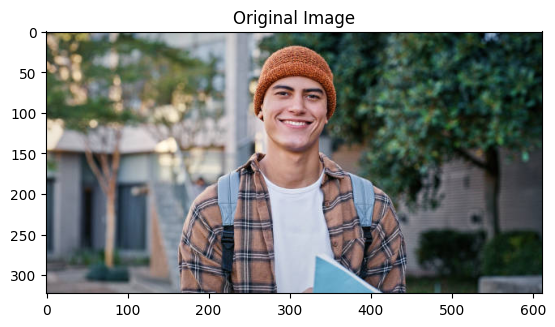

In [32]:
#Displaying the Image
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis('on')
plt.show()

In [116]:
mask = np.zeros_like(img)
roi = img[50:180, 230:360]
mask[50:180, 230:360] = roi

In [117]:
segmented_roi = cv2.bitwise_and(img, mask)

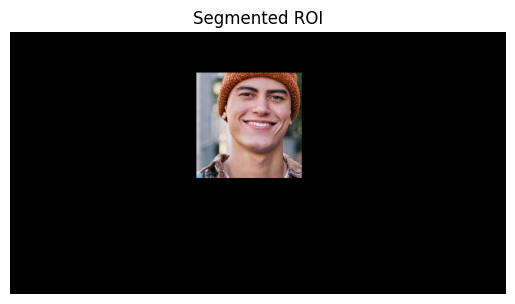

In [118]:
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)
plt.imshow(segmented_roi_rgb)
plt.title("Segmented ROI")
plt.axis('off')
plt.show()

In [119]:
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [120]:
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0) 

In [121]:
edges = cv2.Canny(blurred_image, 50, 150)

(np.float64(-0.5), np.float64(611.5), np.float64(322.5), np.float64(-0.5))

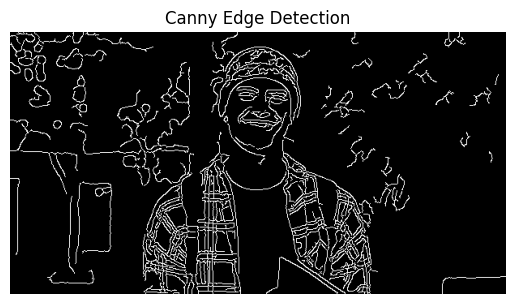

In [122]:
# Canny Edge Detection
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

In [123]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [125]:
result_image = img.copy() 
for contour in contours:
    if cv2.contourArea(contour) > 50: 
        x, y, w, h = cv2.boundingRect(contour)  
        cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  

(np.float64(-0.5), np.float64(611.5), np.float64(322.5), np.float64(-0.5))

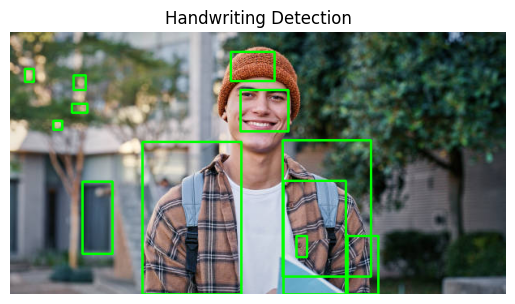

In [126]:
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Handwriting Detection")
plt.axis('off')

In [206]:
config_file = "deploy.prototxt.txt"
weights = "res10_300x300_ssd_iter_140000_fp16.caffemodel"

In [207]:
net = cv2.dnn.readNetFromCaffe(config_file, weights)

In [208]:
class_labels = {0: 'background', 1: 'aeroplane', 2: 'bicycle', 3: 'bird', 4: 'boat',
                5: 'bottle', 6: 'bus', 7: 'car', 8: 'cat', 9: 'chair', 10: 'cow', 11: 'diningtable',
                12: 'dog', 13: 'horse', 14: 'motorbike', 15: 'person', 16: 'pottedplant', 17: 'sheep',
                18: 'sofa', 19: 'train', 20: 'tvmonitor'}

In [209]:

image = cv2.imread('img2.jpg')  
(h, w) = image.shape[:2]

In [210]:

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [213]:
blob = cv2.dnn.blobFromImage(img, 1.0, (300, 300),
                             (104.0, 177.0, 123.0))

In [214]:
net.setInput(blob)
detections = net.forward()

In [215]:
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.5:  # Confidence threshold
        index = int(detections[0, 0, i, 1])  # Get class index
        label = class_labels[index]  # Get label name
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
# Step 8: Draw rectangles and labels on the image
        cv2.rectangle(image_rgb, (startX, startY), (endX, endY), (0, 255, 0), 2)
        cv2.putText(image_rgb, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

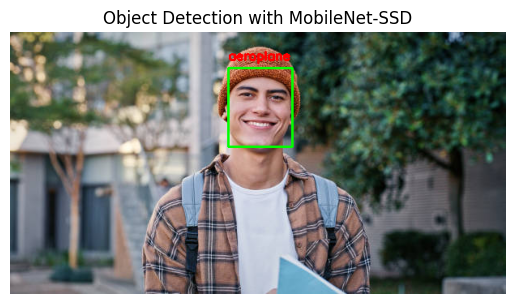

In [216]:
plt.imshow(image_rgb)
plt.title("Object Detection with MobileNet-SSD")
plt.axis("off")
plt.show()